# Internship Project — Week 2

# Employee Attrition Prediction using Machine Learning

# Step 1: Library Loading

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,classification_report,ConfusionMatrixDisplay,roc_curve

### Employee attrition is a major challenge for organizations as it leads to increased recruitment costs, training expenses, and reduced productivity. By analyzing employee data, organizations can identify patterns associated with employee turnover and take proactive measures to improve employee retention.
### The objective of this project is to develop a machine learning model that predicts whether an employee is likely to leave the company based on various personal and workplace factors. Additionally, the project aims to provide actionable business insights that can support HR in making informed retention decisions.

# Step 2: Dataset loading and Exploration

In [56]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv") # loads the IBM HR Analytics Employee Attrition dataset into a Pandas DataFrame

In [57]:
# Exploration

In [58]:
df.head() # displays first 5 rows by default

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [59]:
df.head(10) # displays first 10 rows

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [60]:
df.shape # Checks no. of rows and columns

(1470, 35)

In [61]:
df.info() #dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [62]:
df.describe() # dataset summary

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [63]:
# Here, target column is 'Attrition'. 
df["Attrition"].value_counts() # gives no. of values with values "yes" and "no", i.e. employees who left and employees who stayed resp.

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [64]:
# Attrition Rate as percentage
left = df["Attrition"].value_counts()["Yes"]
attrition_rate = (left / len(df)) * 100
print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


### Observation: Out of 1,470 employees, 237 left the company, resulting in an attrition rate of approximately 16.12%. Since the majority of employees stayed (about 84%), the dataset is imbalanced. This imbalance should be considered while training machine learning models to ensure they do not become biased toward predicting that employees will stay.

# Step 3: Data Cleaning & Preprocessing

In [65]:
df.isna() # checks columns with missing values

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1466,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1467,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1468,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [66]:
df.isna().sum() # checks no. of missing values in each column

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [67]:
df.duplicated().sum() # checks for no. of duplicated columns

np.int64(0)

In [68]:
df.drop(columns=["EmployeeCount","EmployeeNumber","Over18","StandardHours"], inplace=True) # these columns are constant or irrelevant and therefore, add no value to the prediction

In [69]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,3,Male,...,3,3,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,4,Male,...,3,1,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,2,Male,...,4,2,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,4,Male,...,3,4,0,17,3,2,9,6,0,8


# One-hot encoding

In [70]:
df["Attrition"] = df["Attrition"].map({"Yes":1,"No":0})
df = pd.get_dummies(df, drop_first=True)

In [71]:
df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


In [72]:
# Separating Features and Target
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [73]:
X.columns

Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Research Scienti

In [74]:
# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

### Since employee attrition is an imbalanced target variable, the dataset was split using stratify=y to preserve the original proportion of employees who stayed and those who left in both the training and testing sets. This helps ensure fair model training and reliable evaluation.

In [75]:
# Scaling using standard scaler 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # Scale only the training data first
X_test_scaled = scaler.transform(X_test) # Use the same scaling on the test data

### Some features have very different ranges, like, Age, MonthlyIncome, etc. StandardScaler transforms each numeric feature to have mean approx. equal to 0 and std. deviation approx. equal to 1, thus, preventing features with large values (like income) from dominating those with smaller values.

In [76]:
print(np.mean(X_train_scaled, axis=0)) # to check mean

[-4.22942105e-17  1.35945676e-16 -4.68257330e-17  8.76094360e-17
  1.51050752e-17 -3.77626879e-18  2.53765263e-16  7.70358833e-17
  1.60113797e-16 -7.93016446e-17  7.55253758e-18 -5.73992856e-17
 -1.48029737e-16 -5.69461334e-16  1.23861616e-16 -3.92731954e-17
 -7.28819877e-17  3.62521804e-17 -6.94833458e-17 -1.58603289e-17
  5.58887781e-17 -9.66724811e-17  7.85463909e-17  3.85179417e-17
  2.26576127e-17 -1.35945676e-16 -5.89097931e-17  2.41681203e-17
  3.02101503e-17 -5.43782706e-17 -9.06304510e-18 -5.13572556e-17
  6.04203007e-17  3.13430310e-17 -2.41681203e-17  7.70358833e-17
  4.22942105e-17  7.40148683e-17 -1.35945676e-17 -1.20840601e-17
 -6.41965695e-18  3.32311654e-17 -3.32311654e-17  5.43782706e-17]


In [77]:
print(np.std(X_train_scaled, axis=0)) # to check standard deviation

[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Step 4: Exploratory Data Analysis (EDA)

# NOTE: EDA is conducted on the original dataset because one-hot encoding creates multiple binary columns for each categorical feature, making the data more difficult to interpret and visualize.

In [78]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [79]:
# For EDA
eda_df = df.copy()

In [80]:
# For preprocessing
df = pd.get_dummies(df, drop_first=True)

## 1. Attrition Rate by Department
## This analysis examines whether employee attrition varies across different departments, helping identify areas where HR may need to focus retention efforts.

In [81]:
department_groups = eda_df.groupby("Department") # Group employees by department
department_attrition = department_groups["Attrition"].apply(lambda x: (x == "Yes").mean() * 100) # Calculate percentage of employees who left
department_attrition = department_attrition.sort_values(ascending=False) # Sort from highest to lowest attrition

In [82]:
department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

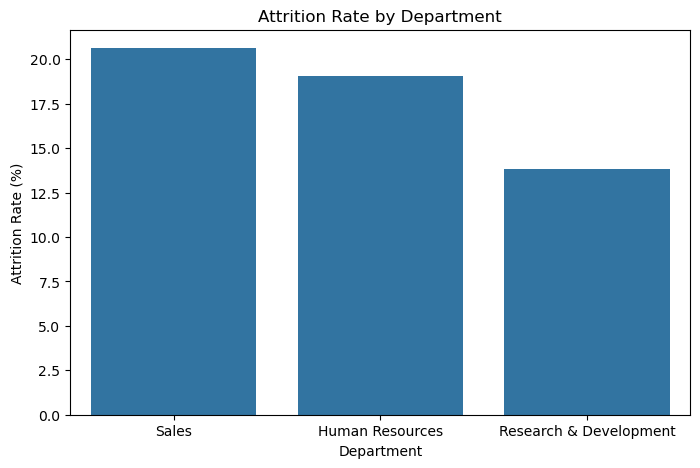

In [83]:
plt.figure(figsize=(8,5))
sns.barplot(x=department_attrition.index,y=department_attrition.values)
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")
plt.savefig("AttritionRateByDept.png")
plt.show()

### Observation: The Sales department has the highest attrition rate at approximately 20.6%, followed by Human Resources at around 19.0%. In contrast, Research & Development (R&D) has the lowest attrition rate at approximately 13.8%. This indicates that employees in the Sales and Human Resources departments are leaving the organization more frequently than those in R&D.

## 2. Attrition Rate by Job Role

## This analysis examines the attrition rate across different job roles to identify positions with the highest employee turnover. Understanding which roles experience higher attrition can help HR prioritize retention strategies and address role-specific challenges.

In [84]:
jobrole_attrition = (eda_df.groupby("JobRole")["Attrition"].apply(lambda x: (x == "Yes").mean() * 100).sort_values(ascending=False))

In [85]:
jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

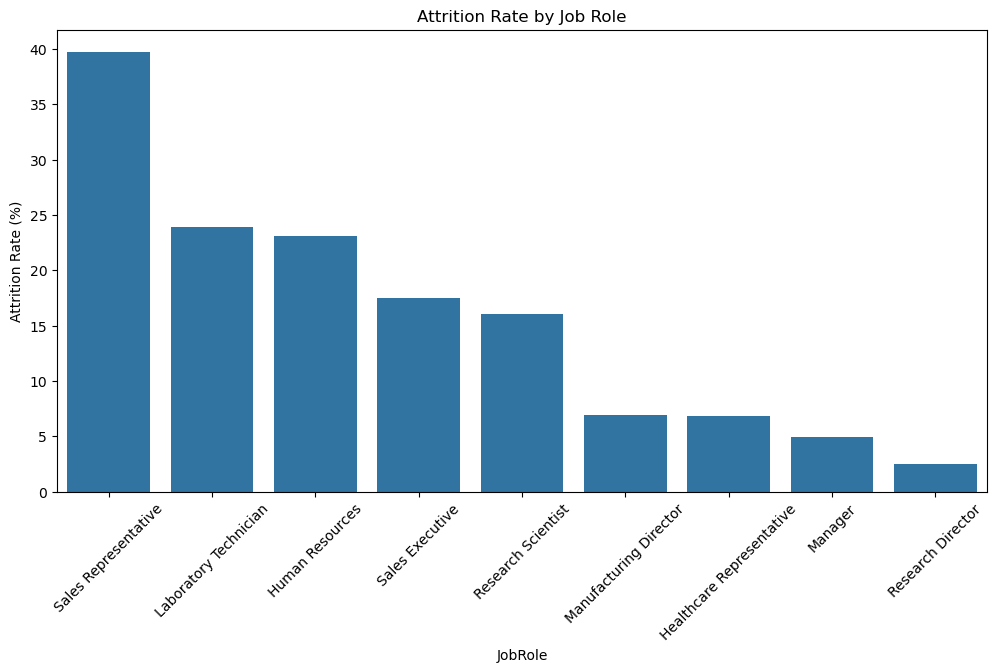

In [86]:
plt.figure(figsize=(12,6))
sns.barplot(x=jobrole_attrition.index,y=jobrole_attrition.values)
plt.xticks(rotation=45) # rotates the x-axis labels by 45 degrees for better readability
plt.title("Attrition Rate by Job Role")
plt.ylabel("Attrition Rate (%)")
plt.savefig("AttritionRateByJobRole.png")
plt.show()

### Observation: The Sales Representative role has the highest attrition rate at approximately 39.8%, indicating that nearly 4 out of every 10 employees in this role leave the organization. Laboratory Technicians (approximately 24.0%) and Human Resources employees (approximately 23.1%) also experience relatively high attrition. In contrast, Research Directors have the lowest attrition rate at approximately 2.5%, followed by Managers at around 5%.

## 3. Attrition Rate by Monthly Income (Attrition vs Monthly Income)
## This analysis compares the monthly income of employees who stayed with those who left the organization. The objective is to determine whether salary appears to influence employee attrition.

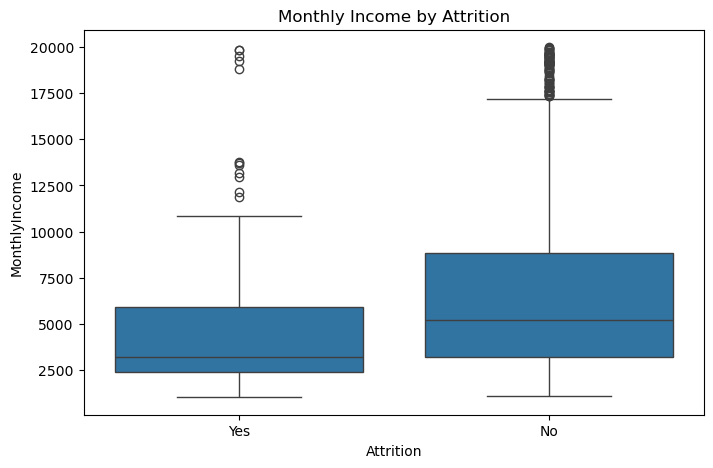

In [87]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition",y="MonthlyIncome",data=eda_df)
plt.title("Monthly Income by Attrition")
plt.savefig("MonthlyIncomeByAttrition.png")
plt.show()

In [88]:
eda_df.groupby("Attrition")["MonthlyIncome"].mean()

Attrition
No     6832.739659
Yes    4787.092827
Name: MonthlyIncome, dtype: float64

### A box plot is used because **Monthly Income** is a continuous numerical variable, while **Attrition** is a categorical variable with two groups (Yes and No). The box plot allows us to compare the distribution of salaries between employees who left and those who stayed by displaying the median, spread, and outliers. This provides a more complete picture than simply comparing average salaries.
### Observation: Employees who left the organization generally have a lower median monthly income than employees who stayed. While there are a few high-income employees who also left, the overall distribution suggests that lower-income employees are more likely to experience attrition. However, the presence of high-income outliers indicates that salary alone does not fully explain employee turnover.

## 4. Attrition vs Work-Life Balance

## This analysis investigates whether employees' work-life balance ratings are associated with attrition. Understanding this relationship helps determine whether work-life balance influences employee retention.

In [89]:
worklife = (eda_df.groupby("WorkLifeBalance")["Attrition"].apply(lambda x: (x=="Yes").mean()*100))

In [90]:
worklife

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

In [91]:
labels = {
    1: "Poor",
    2: "Fair",
    3: "Good",
    4: "Excellent"
}
worklife.index = worklife.index.map(labels)

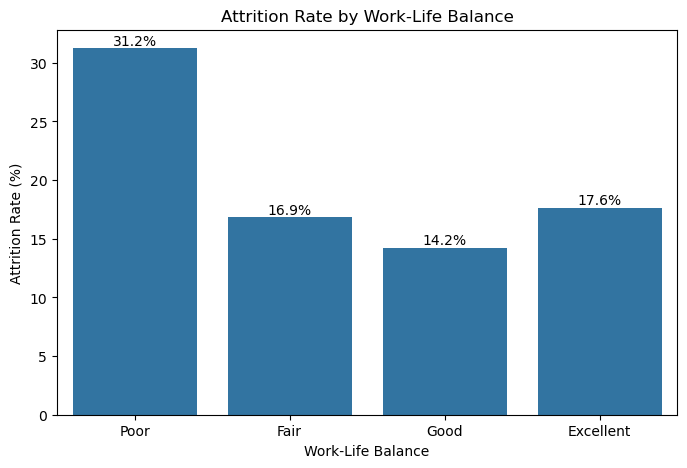

In [92]:
plt.figure(figsize=(8,5))
ax = sns.barplot(x=worklife.index,y=worklife.values)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')
plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")
plt.savefig("AttritionRateByWorkLife.png")
plt.show()

### Observation: Employees with the lowest work-life balance rating (1-Poor) have the highest attrition rate at approximately 31.2%, which is nearly double the overall attrition rate of the organization. Attrition decreases substantially for ratings 2-Fair  and 3-Poor. Although employees with the highest work-life balance rating 4-Excellent show a slight increase in attrition (approximately 17.6%), it remains significantly lower than the rate for employees with the poorest work-life balance.

## 5. Attrition vs Years at Company

## This analysis explores whether employee tenure influences attrition. Understanding when employees are most likely to leave can help HR implement targeted retention strategies during critical stages of employment.

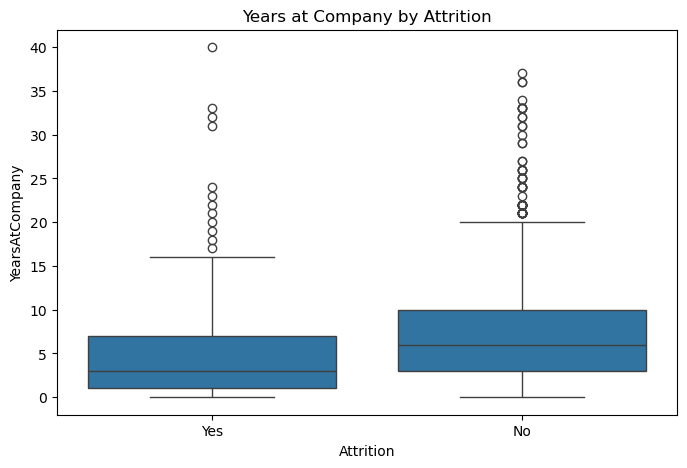

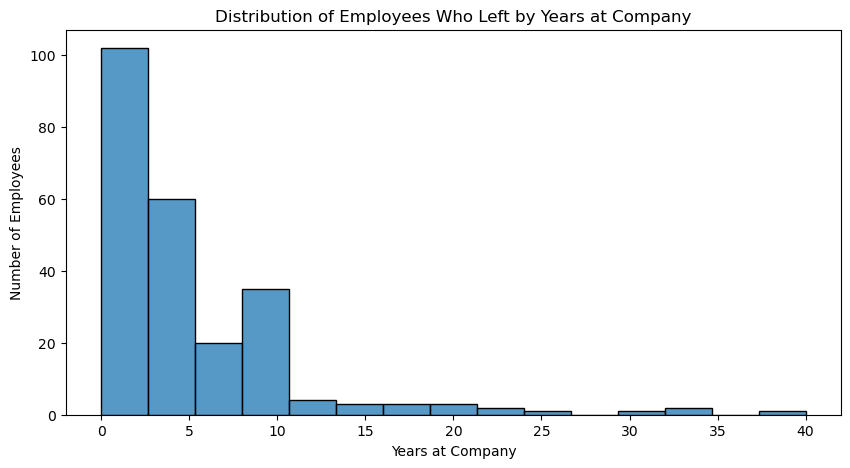

In [93]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition",y="YearsAtCompany",data=eda_df)
plt.title("Years at Company by Attrition")
plt.savefig("AttritionVSYearsAtCompany.png")
plt.show()
plt.figure(figsize=(10,5))

sns.histplot(
    data=eda_df[eda_df["Attrition"] == "Yes"],
    x="YearsAtCompany",
    bins=15
)

plt.title("Distribution of Employees Who Left by Years at Company")
plt.xlabel("Years at Company")
plt.ylabel("Number of Employees")
plt.savefig("DistOfEmployees.png")
plt.show()

### Observation: Employees who left the organization generally have a shorter tenure than those who stayed. The median years at the company for employees who left is approximately 3 years, compared to approximately 6 years for employees who remained. This indicates that attrition is more common during the early years of employment. Although a few long-tenured employees also left the organization, they represent a relatively small proportion of the workforce.

## Business Insights from EDA

### 1. **Sales experiences the highest employee turnover among departments.**
   ### The Sales department records the highest attrition rate (**20.6%**), followed by Human Resources (**19.0%**), while Research & Development has the lowest attrition rate (**13.8%**). This suggests that HR should prioritize retention efforts in the Sales department, where employees are leaving at a considerably higher rate.

### 2. **Sales Representatives are the most vulnerable to attrition.**
   ### Nearly **40%** of Sales Representatives leave the organization, making this the highest-risk job role. Laboratory Technicians (**24.0%**) and Human Resources employees (**23.1%**) also show relatively high turnover, whereas Research Directors (**2.5%**) and Managers (**5.0%**) have the lowest attrition rates. This indicates that retention strategies should focus on specific job roles rather than treating all employees equally.

### 3. **Lower income is associated with higher attrition, but it is not the only factor.**
   ### Employees who left the company generally have a lower median monthly income than those who stayed. However, the presence of several high-income employees among those who left indicates that increasing salary alone may not eliminate attrition. Other workplace factors such as career growth, workload, and job satisfaction should also be considered.

### 4. **Poor work-life balance is strongly associated with employee turnover.**
   ### Employees with the lowest work-life balance rating (**1**) have an attrition rate of approximately **31.3%**, which is almost twice that of employees with ratings **2** (**16.9%**) and **3** (**14.3%**). This suggests that improving work-life balance through flexible work policies, workload management, and employee well-being initiatives could significantly reduce attrition.

### 5. **Most employees leave during the early years of employment.**
   ### Employees who left the company have a median tenure of approximately **3 years**, compared with approximately **6 years** for employees who stayed. This indicates that the first few years of employment are the most critical period for retention. Strengthening onboarding, mentoring, and career development programs for new employees may help improve long-term employee retention.


# Step 5: Model Building and Comparison

## NOTE: The dataset was already divided into training and testing sets using an 80:20 split during preprocessing. Numeric features were standardized using `StandardScaler` to ensure consistent feature scaling before training the machine learning models.

## 1. Logistic Regression

In [94]:
lr = LogisticRegression(class_weight="balanced",random_state=42,max_iter=1000)

In [95]:
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## 2. Random Forest

In [96]:
rf = RandomForestClassifier(n_estimators=200,class_weight="balanced",random_state=42)

In [97]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 3. Gradient Boosting
## NOTE: GradientBoostingClassifier in scikit-learn does not provide a class_weight parameter. Therefore, the model is trained using the original class distribution.

In [98]:
gb = GradientBoostingClassifier(random_state=42)

In [99]:
gb.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


# Step 6: Model Evaluation

## Function for model evaluation

In [100]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    cm = confusion_matrix(y_test, y_pred)
    return precision, recall, f1, roc, cm

In [101]:
lr_results = evaluate_model(
    lr,
    X_test_scaled,
    y_test
)

rf_results = evaluate_model(
    rf,
    X_test,
    y_test
)

gb_results = evaluate_model(
    gb,
    X_test_scaled,
    y_test
)

In [102]:
comparison = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision":[
        lr_results[0],
        rf_results[0],
        gb_results[0]
    ],

    "Recall":[
        lr_results[1],
        rf_results[1],
        gb_results[1]
    ],

    "F1 Score":[
        lr_results[2],
        rf_results[2],
        gb_results[2]
    ],

    "ROC-AUC":[
        lr_results[3],
        rf_results[3],
        gb_results[3]
    ]
})

In [103]:
comparison

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.444444,0.085106,0.142857,0.770695
2,Gradient Boosting,0.588235,0.212766,0.312500,0.794125


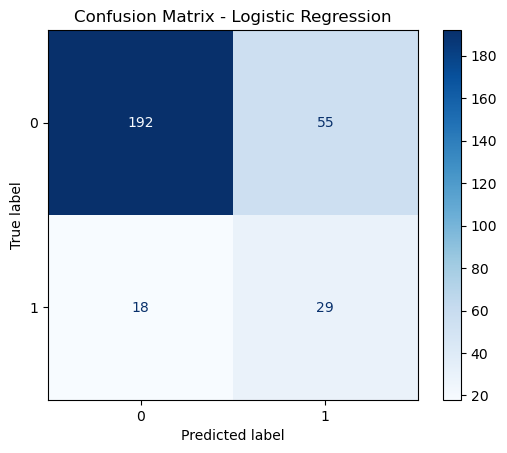

In [104]:
ConfusionMatrixDisplay.from_estimator(lr,X_test_scaled,y_test,cmap="Blues")
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig("ConfusionMatrixLR.png")
plt.show()

In [105]:
importance = pd.DataFrame({"Feature": X.columns,"Importance": abs(lr.coef_[0])})
importance = importance.sort_values(by="Importance",ascending=False)

In [106]:
importance.head(10)

,Feature,Importance
34,JobRole_Laboratory Technician,0.810172
43,OverTime_Yes,0.771095
23,BusinessTravel_Travel_Frequently,0.722538
16,TotalWorkingYears,0.660270
7,JobLevel,0.650173
40,JobRole_Sales Representative,0.531090
24,BusinessTravel_Travel_Rarely,0.512780
27,EducationField_Life Sciences,0.512319
21,YearsSinceLastPromotion,0.499063
26,Department_Sales,0.470587


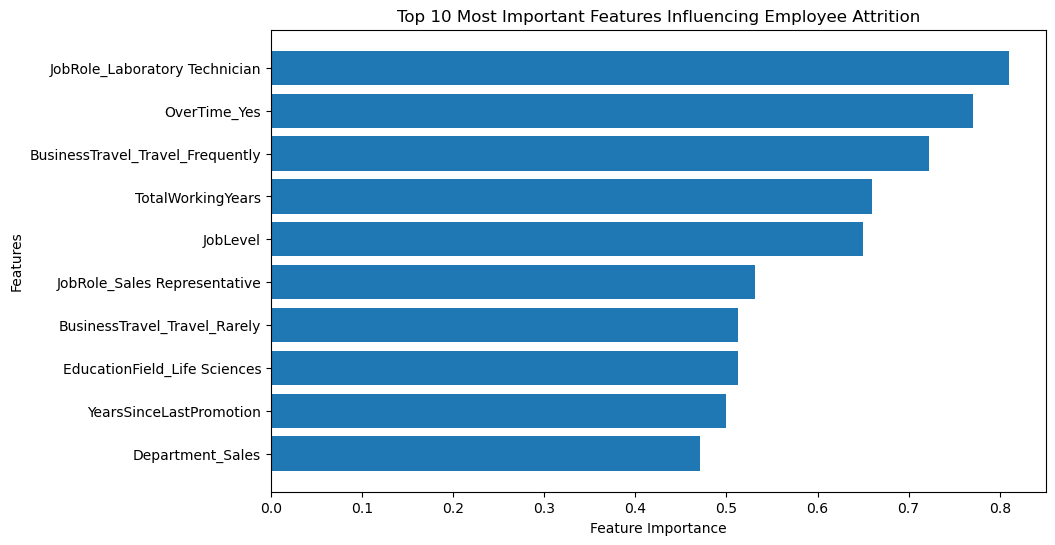

In [107]:
top10 = importance.head(10).sort_values(by="Importance")
plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Most Important Features Influencing Employee Attrition")
plt.savefig("Top10ImpFeatures.png")
plt.show()

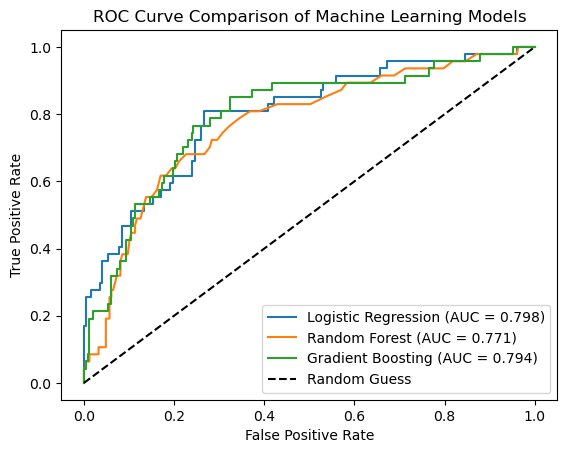

In [108]:
# Logistic Regression
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, lr_prob)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, lr_prob):.3f})")

# Random Forest
rf_prob = rf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, rf_prob)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc_score(y_test, rf_prob):.3f})")

# Gradient Boosting
gb_prob = gb.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, gb_prob)
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_prob):.3f})")

# Random classifier
plt.plot([0,1], [0,1], 'k--', label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Machine Learning Models")
plt.legend()
plt.savefig("ROC_Curve.png")
plt.show()

## The Receiver Operating Characteristic (ROC) curve compares the ability of each model to distinguish between employees who are likely to leave and those who are likely to stay. A model with a larger Area Under the Curve (ROC-AUC) demonstrates better overall classification performance.
## The Logistic Regression model achieved the highest ROC-AUC score (**0.798**), followed closely by Gradient Boosting (**0.794**), while Random Forest obtained the lowest ROC-AUC score (**0.771**). Although the ROC-AUC values are relatively similar, Logistic Regression demonstrated the best overall ability to distinguish between employees who are likely to leave and those who are likely to stay.

# HR Insights & Business Recommendations

## The analysis indicates that **job role**, **overtime**, and **frequent business travel** are among the strongest factors influencing employee attrition. In particular, employees working as **Sales Representatives** and **Laboratory Technicians**, as well as those who frequently work overtime or travel regularly for business, appear to be at a higher risk of leaving the organization. Based on the exploratory analysis, the **Sales department** should be prioritized for retention efforts, as it recorded the highest departmental attrition rate (approximately **20.6%**), while **Sales Representatives** showed the highest attrition among all job roles (approximately **39.8%**). Although employees who left generally earned lower salaries, salary alone does not explain attrition; work-life balance, overtime, travel requirements, and job-related factors also play important roles. 

## To improve retention, the company should 
## (1) identify employees who frequently work overtime or travel and conduct regular retention conversations while promoting healthier work-life balance 
## (2) strengthen onboarding, mentoring, and career development programs for employees during their first few years and for high-risk job roles such as Sales Representatives and Laboratory Technicians. 
## A limitation of this model is that it predicts attrition based only on the available historical employee data and cannot account for personal circumstances, organizational changes, or future events. Therefore, the model should be used as a decision-support tool rather than the sole basis for HR decisions.